Enter the start point Bhopal
Enter end point Gwalior


BFS Path: ['Bhopal', 'Indore', 'Gwalior']
DFS Path: ['Bhopal', 'Indore', 'Ujjain', 'Gwalior']
UCS Path: ['Bhopal', 'Indore', 'Gwalior'] Cost: 690


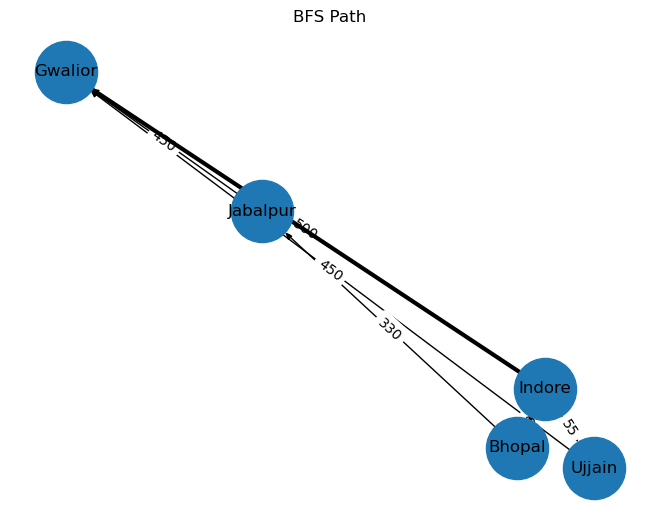

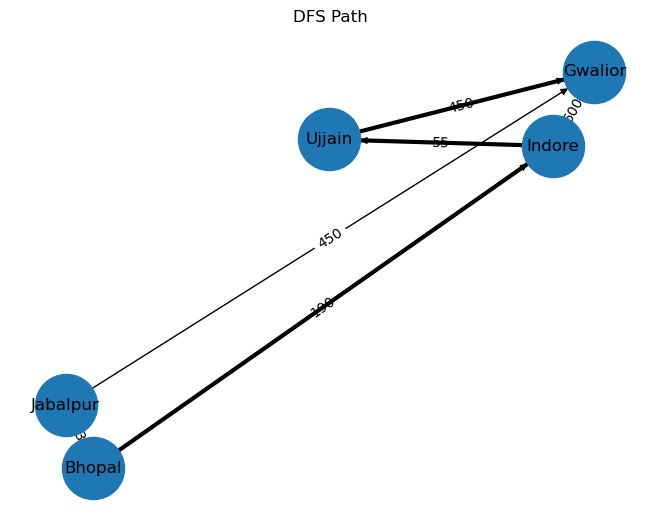

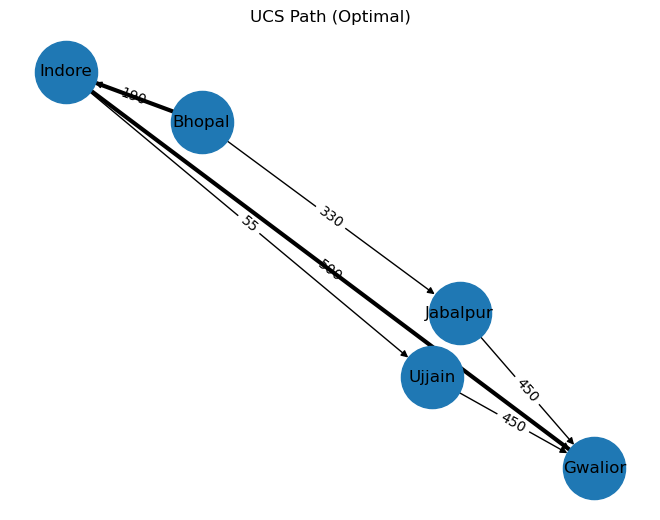

In [3]:
from collections import deque
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Graph with weights
graph = {
    'Bhopal': {'Indore': 190, 'Jabalpur': 330},
    'Indore': {'Ujjain': 55, 'Gwalior': 500},
    'Jabalpur': {'Gwalior': 450},
    'Ujjain': {'Gwalior': 450},
    'Gwalior': {}
}

# Convert to NetworkX graph
G = nx.DiGraph()
for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)


# BFS
def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append((neighbor, path + [neighbor]))

    return None


# DFS
def dfs(graph, start, goal, path=[]):
    path = path + [start]

    if start == goal:
        return path

    for neighbor in graph[start]:
        if neighbor not in path:
            result = dfs(graph, neighbor, goal, path)
            if result:
                return result

    return None


# UCS
def ucs(graph, start, goal):
    pq = [(0, start, [start])]
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node == goal:
            return cost, path

        if node not in visited:
            visited.add(node)
            for neighbor, weight in graph[node].items():
                heapq.heappush(pq, (cost + weight, neighbor, path + [neighbor]))

    return None


# Visualization function
def draw_graph(path=None, title="Graph"):
    pos = nx.spring_layout(G)

    plt.figure()

    # Draw nodes & edges
    nx.draw(G, pos, with_labels=True, node_size=2000)

    # Draw edge weights
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # Highlight path
    if path:
        edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=3)

    plt.title(title)
    plt.show()


# Run
start = input("Enter the start point")
goal = input("Enter end point")

bfs_path = bfs(graph, start, goal)
dfs_path = dfs(graph, start, goal)
ucs_cost, ucs_path = ucs(graph, start, goal)

print("BFS Path:", bfs_path)
print("DFS Path:", dfs_path)
print("UCS Path:", ucs_path, "Cost:", ucs_cost)

# Visualize
draw_graph(bfs_path, "BFS Path")
draw_graph(dfs_path, "DFS Path")
draw_graph(ucs_path, "UCS Path (Optimal)")